# 04. Spatial domains, and how a cell's state depends on where it is

**Author:** MD Shakhaowat Hossain, PhD Candidate, Loren Gragert Lab, Tulane University School of Medicine · [Project website](https://hossainms.github.io/xenium-human-lung-cancer-ffpe/) · [Code](https://github.com/hossainms/xenium-human-lung-cancer-ffpe)

**Why:** cell types say *what* is in the tissue; domains say *how it is organised*: tumour nests, tumour borders, stroma, vessels, lymphoid aggregates. The Step 7 niches did this with k-means on neighbourhood composition, a simple baseline. Here two methods built for Xenium-scale data are applied, compared with the baseline, and then used to ask the central question of spatial biology: **does the same cell type change its expression depending on where it sits?**

**Methods**
- **BANKSY** (Singhal et al., *Nature Genetics* 2024): each cell's expression is augmented with the average expression of its spatial neighbours; λ sets the balance (λ = 0.8 is the recommended domain-finding mode). Then PCA + Leiden.
- **CellCharter** (Varrone et al., *Nature Genetics* 2024): each cell's embedding is concatenated with the mean embeddings of its 1st, 2nd and 3rd-order spatial neighbours, then clustered with a Gaussian mixture. It picks the number of domains by **stability**: the K whose clustering is most reproducible across repeated runs.
- **Pseudobulk differential expression** with PyDESeq2, comparing one macrophage type between domains.

| Part | Content |
|---|---|
| A | Data |
| B | BANKSY, and how stable its domains are across parameters |
| C | CellCharter, with automatic choice of the number of domains |
| D | Compare the three domain sets (k-means niches, BANKSY, CellCharter) |
| E | Same cell type, different domain: pseudobulk differential expression |
| F | Export for Xenium Explorer |

## Setup

In [1]:
from ist_analysis import domains as dm
from ist_analysis import utils as xu   # paths and constants shared with the core workflow and the pipeline

xu.check_kernel()

import contextlib
import io
import logging
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from IPython.display import display
from sklearn.metrics import adjusted_rand_score as ari

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
OUT_DIR = xu.output_dir("spatial_domains")
print(f"Outputs go to {xu.display_path(OUT_DIR)}")

Outputs go to ~/data/xenium_lung/processed/spatial_domains


## A. Data

The Step 9 object: the 139,129 high-confidence cells of the core workflow, with log-normalised expression, cell types, the Step 7 k-means niches and distance to the nearest tumour cell.

In [2]:
adata = xu.load_step("time")
adata.X = adata.layers["lognorm"].copy()
xy = adata.obsm["spatial"]
adata.obs["x"], adata.obs["y"] = xy[:, 0], xy[:, 1]
domains = pd.DataFrame({"niche": adata.obs["niche"].astype(str)}, index=adata.obs_names)   # all domain labels, collected
lineage = adata.obs["lineage"].astype(str)
print(f"{adata.n_obs:,} cells x {adata.n_vars} genes; tissue {np.ptp(xy[:, 0]) / 1000:.1f} x {np.ptp(xy[:, 1]) / 1000:.1f} mm")
print(f"Step 7 k-means niches: {domains['niche'].nunique()}")

139,129 cells x 377 genes; tissue 10.8 x 3.2 mm
Step 7 k-means niches: 10


## B. BANKSY

**Parameters:** 15 nearest neighbours with Gaussian distance weights; no azimuthal Gabor filter (`max_m = 0`, as in the R workflow); 20 PCs; Leiden.

**Stability check.** A domain map is only worth interpreting if it does not change much when the parameters do. BANKSY is run on a grid (λ = 0.5 / 0.8 / 0.9 x resolution 0.1-0.3) and every setting is compared with the chosen one (λ = 0.8, resolution 0.2) by ARI (1 = identical partition, 0 = chance).

In [3]:
LAMBDAS, RESOLUTIONS = [0.5, 0.8, 0.9], [0.1, 0.15, 0.2, 0.3]
CHOSEN = (0.8, 0.2)
t0 = time.time()
grid = dm.banksy_grid(adata, LAMBDAS, RESOLUTIONS)   # (lambda, resolution) -> domain labels; pybanksy, 15 neighbours, max_m 0
print(f"BANKSY: {len(grid)} parameter settings in {time.time() - t0:.0f} s")

chosen = grid[CHOSEN]
stab, n_dom = dm.grid_stability(grid, CHOSEN, LAMBDAS, RESOLUTIONS)
display(stab.style.format("{:.2f}").background_gradient(cmap="Greens", vmin=0, vmax=1)
        .set_caption(f"ARI with the chosen setting (lambda {CHOSEN[0]}, resolution {CHOSEN[1]})"))
display(n_dom.style.set_caption("Number of domains"))
domains["banksy"] = chosen

BANKSY: 12 parameter settings in 71 s


,res 0.1,res 0.15,res 0.2,res 0.3
lambda 0.5,0.60,0.62,0.63,0.54
lambda 0.8,0.65,0.81,1.00,0.82
lambda 0.9,0.68,0.58,0.58,0.84


,res 0.1,res 0.15,res 0.2,res 0.3
lambda 0.5,7,8,8,12
lambda 0.8,8,8,10,12
lambda 0.9,8,8,8,9


**Reading B.** Within domain mode (λ 0.8-0.9), neighbouring resolutions agree at ARI ~0.8, so the chosen map is not a knife-edge result. λ = 0.5 (more weight on each cell's own expression) moves the partition further: it starts to split by cell type rather than by neighbourhood, which is what λ is designed to control.

## C. CellCharter

**Embedding:** 30 PCs of the scaled expression, aggregated over 3 layers of the Delaunay graph (long edges removed, as CellCharter recommends). The original method uses an scVI embedding; PCA is the lighter substitute for one sample with no batch effects.

**Number of domains:** `ClusterAutoK` fits Gaussian mixtures for K = 3-13, three times each, and scores how similar the clusterings of neighbouring K are across runs. The most stable K is chosen.

**Reproducibility note:** CellCharter's `random_state` argument does not seed PyTorch, so identical calls gave different domains (ARI 0.64 between two runs). Seeding PyTorch globally first (`seed_everything`) makes runs identical. The fit also runs on the CPU, which was faster than the Mac GPU for this model (~20 s vs ~45 s per fit).

`RECOMPUTE_AUTOK = False` reuses the saved result (~9 min to recompute).

INFO     Creating graph using `None` transform and `1` libraries.                                                  


  0%|          | 0/4 [00:00<?, ?it/s]

CellCharter embedding: 120 dimensions (30 PCs x 4: the cell + 3 neighbour layers)


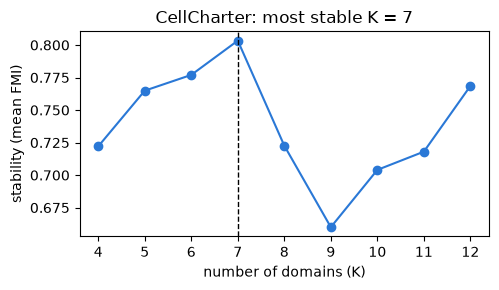

CellCharter: 7 domains


In [4]:
RECOMPUTE_AUTOK = False
AUTOK_FILE = OUT_DIR / "cellcharter_autok.csv.gz"

dm.cellcharter_embedding(adata)   # 30 PCs, aggregated over 3 Delaunay layers (long links removed) -> obsm['X_cellcharter']
print(f"CellCharter embedding: {adata.obsm['X_cellcharter'].shape[1]} dimensions (30 PCs x 4: the cell + 3 neighbour layers)")

if RECOMPUTE_AUTOK or not AUTOK_FILE.exists():
    t0 = time.time()
    labels, stability = dm.cellcharter_autok(adata, (4, 12), runs=3)   # PyTorch seeded explicitly; CPU
    pd.DataFrame({"cellcharter": labels}, index=adata.obs_names).to_csv(AUTOK_FILE)
    stability.to_csv(OUT_DIR / "cellcharter_stability.csv", index_label="K")
    print(f"AutoK fitted in {(time.time() - t0) / 60:.1f} min")
domains["cellcharter"] = pd.read_csv(AUTOK_FILE, index_col=0)["cellcharter"].astype(str).reindex(adata.obs_names)
stability = pd.read_csv(OUT_DIR / "cellcharter_stability.csv", index_col=0)["stability"]
best_k = int(stability.idxmax())

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(stability.index.astype(int), stability.to_numpy(), "o-", color="#2a78d6")
ax.axvline(best_k, color="black", ls="--", lw=1)
ax.set_xlabel("number of domains (K)")
ax.set_ylabel("stability (mean FMI)")
ax.set_title(f"CellCharter: most stable K = {best_k}")
plt.tight_layout()
plt.show()
print(f"CellCharter: {domains['cellcharter'].nunique()} domains")

## D. Compare the domain sets

### D1. What each domain is made of

Every domain is named from its own composition (its top lineages and their %), the same rule as the Step 7 niches, so names are generated from the data rather than chosen by eye.

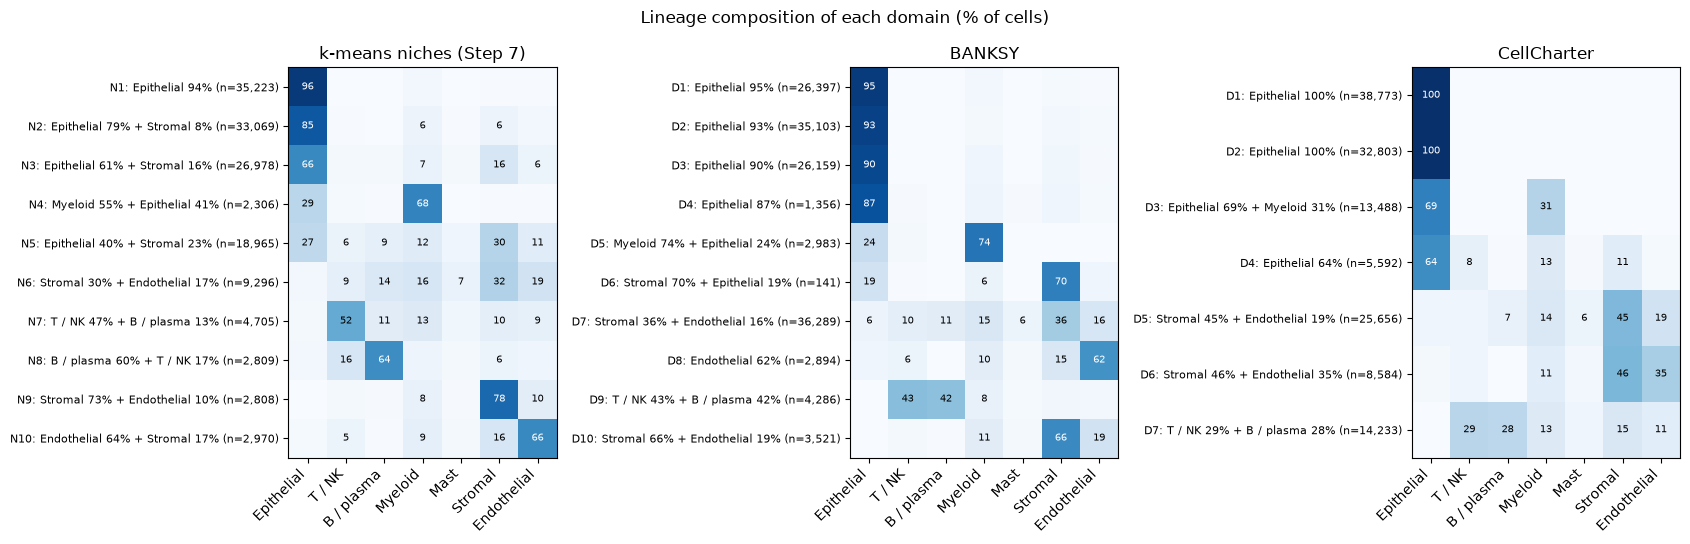

In [5]:
LINEAGES = list(xu.LINEAGE_COLORS)


def name_domains(labels):
    """'D<i>: <top lineage> x% [+ <second> y%]', numbered by decreasing epithelial share (dm.name_domains)."""
    return dm.name_domains(labels, lineage, LINEAGES)


METHODS = {"niche": "k-means niches (Step 7)", "banksy": "BANKSY", "cellcharter": "CellCharter"}
for m in ["banksy", "cellcharter"]:
    domains[m] = name_domains(domains[m])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1, 1, 1]})
for ax, (m, title) in zip(axes, METHODS.items()):
    comp = pd.crosstab(domains[m], lineage, normalize="index").reindex(columns=LINEAGES).fillna(0) * 100
    comp = comp.loc[sorted(comp.index, key=lambda s: int(s.split(":")[0][1:]))]
    ax.imshow(comp.to_numpy(), cmap="Blues", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(LINEAGES)), LINEAGES, rotation=45, ha="right")
    ax.set_yticks(range(len(comp)), [f"{d} (n={n:,})" for d, n in domains[m].value_counts().reindex(comp.index).items()], fontsize=8)
    for i in range(comp.shape[0]):
        for j in range(comp.shape[1]):
            if comp.iat[i, j] >= 5:
                ax.text(j, i, f"{comp.iat[i, j]:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if comp.iat[i, j] > 60 else "black")
    ax.set_title(title)
plt.suptitle("Lineage composition of each domain (% of cells)")
plt.tight_layout()
plt.show()

### D2. Where they are, and how much the methods agree

ARI on raw labels is harsh here: 60% of cells are tumour, and each method divides the tumour mass differently, so a disagreement inside the tumour dominates the score. A second measure therefore groups every domain into one of three **tissue compartments** by its majority (tumour = epithelial majority; immune = T/NK + B/plasma + myeloid + mast majority; stroma / vessels = stromal + endothelial majority) and asks how often two methods put a cell in the same compartment.

,ARI (domains),same compartment (% cells)
pair,,
k-means niches (Step 7) vs BANKSY,0.17,86
k-means niches (Step 7) vs CellCharter,0.29,79
BANKSY vs CellCharter,0.26,85


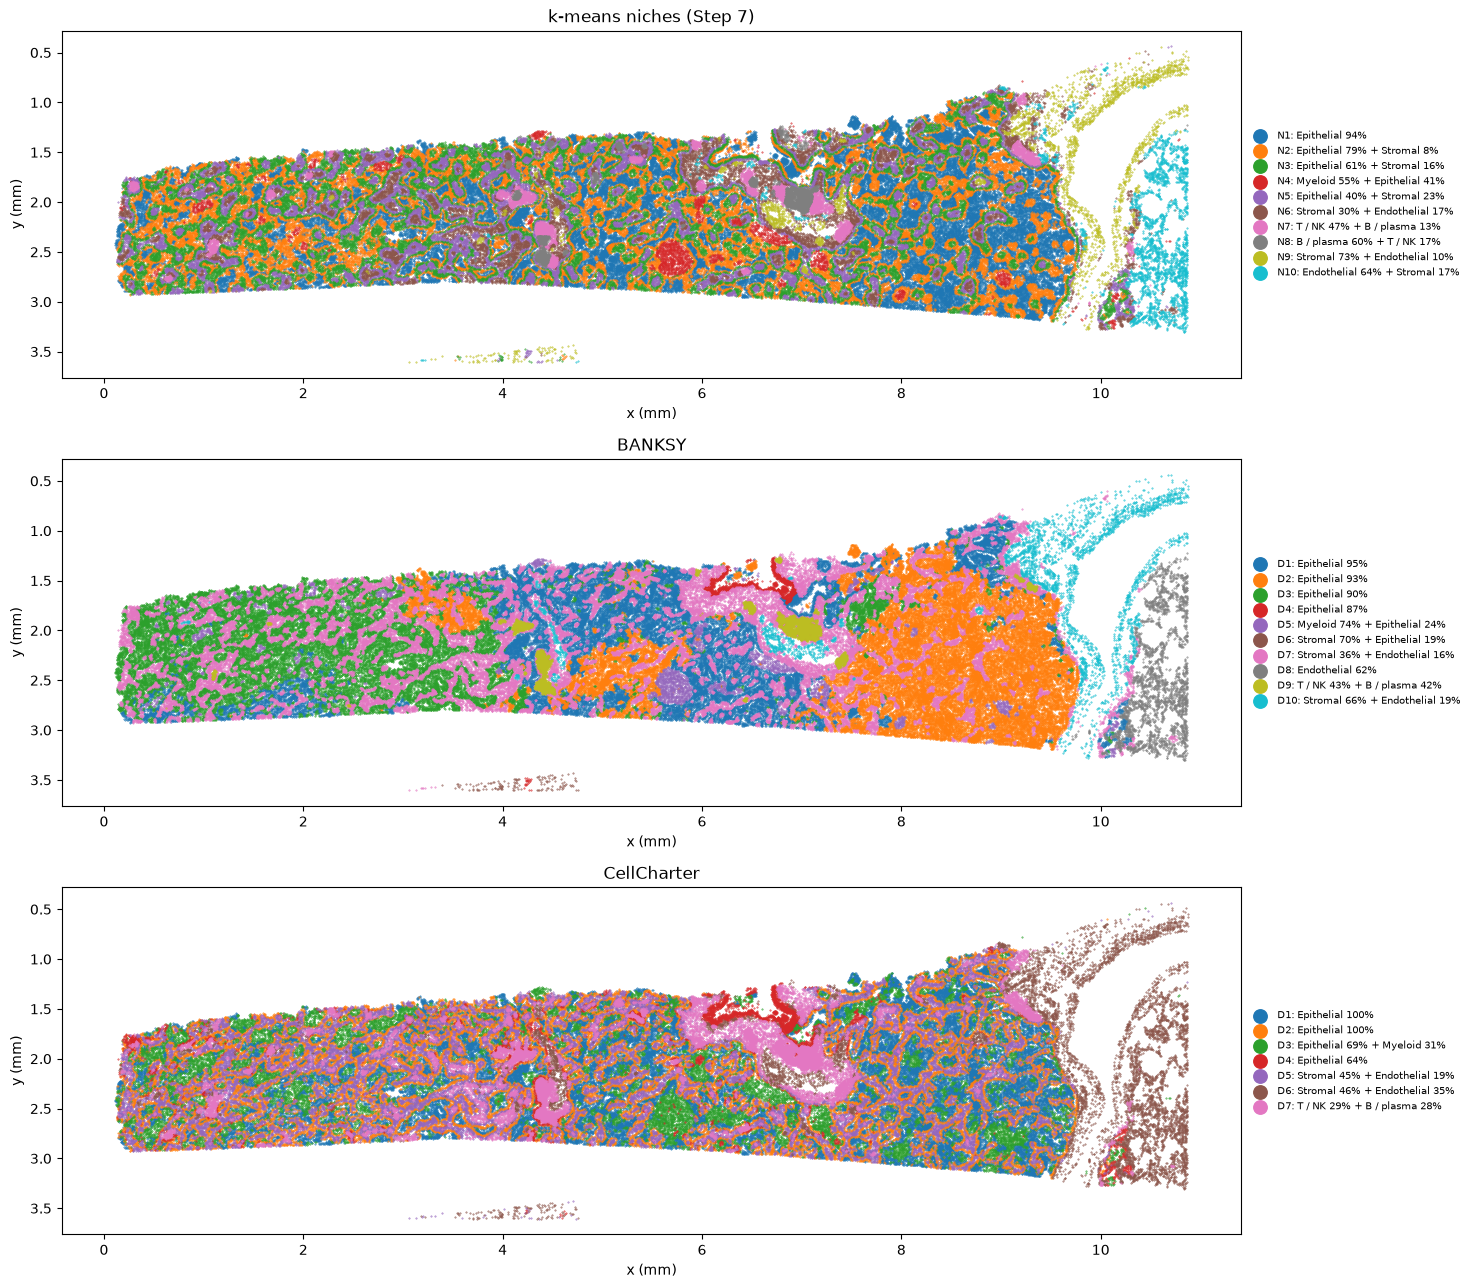

In [6]:
COMPARTMENT = dm.COMPARTMENT   # lineage -> tumour / immune / stroma + vessels
compartments = pd.DataFrame({m: dm.compartment(domains[m], lineage) for m in METHODS})
pairs = [("niche", "banksy"), ("niche", "cellcharter"), ("banksy", "cellcharter")]
agree = pd.DataFrame([{"pair": f"{METHODS[a]} vs {METHODS[b]}", "ARI (domains)": ari(domains[a], domains[b]),
                       "same compartment (% cells)": 100 * (compartments[a] == compartments[b]).mean()} for a, b in pairs]).set_index("pair")
display(agree.style.format({"ARI (domains)": "{:.2f}", "same compartment (% cells)": "{:.0f}"}))

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
for ax, (m, title) in zip(axes, METHODS.items()):
    labs = domains[m]
    order = sorted(labs.unique(), key=lambda s: int(s.split(":")[0].lstrip("ND")))
    cmap = plt.get_cmap("tab20" if len(order) > 10 else "tab10")
    for i, d in enumerate(order):
        sel = (labs == d).to_numpy()
        ax.scatter(xy[sel, 0] / 1000, xy[sel, 1] / 1000, s=0.15, color=cmap(i), label=d, rasterized=True)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.legend(markerscale=25, fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
plt.tight_layout()
plt.show()

### D3. Why do BANKSY and CellCharter disagree inside the tumour?

Two properties of each tumour domain: which **tumour subtype** (Step 6) its tumour cells belong to, and how **deep** inside a tumour nest they sit (distance from each epithelial cell to the nearest non-epithelial cell).

In [7]:
from scipy.spatial import cKDTree

is_epi = (lineage == "Epithelial").to_numpy()
depth = pd.Series(cKDTree(xy[~is_epi]).query(xy[is_epi])[0], index=adata.obs_names[is_epi])
tumour = adata.obs_names[adata.obs["cell_type"].isin(xu.TUMOUR_TYPES).to_numpy()]
for m in ["banksy", "cellcharter"]:
    epi_domains = [d for d in sorted(domains[m].unique(), key=lambda s: int(s.split(":")[0][1:])) if "Epithelial" in d.split(":")[1].split("%")[0]]
    sub = pd.crosstab(domains.loc[tumour, m], adata.obs.loc[tumour, "cell_type"], normalize="index").reindex(epi_domains) * 100
    sub.columns = [c.replace("Tumour epithelial ", "").replace("Proliferating tumour", "proliferating") for c in sub.columns]
    sub["median depth in nest (um)"] = depth.groupby(domains.loc[depth.index, m]).median().reindex(epi_domains)
    display(sub.style.format("{:.0f}").background_gradient(cmap="Blues", vmin=0, vmax=100, subset=sub.columns[:-1])
            .set_caption(f"{METHODS[m]}: tumour domains, % of their tumour cells by subtype, and depth"))

,proliferating,(CYP2B6/CFTR),(MALL/TCIM),(MYC/CAPN8),median depth in nest (um)
banksy,,,,,
D1: Epithelial 95%,2,78,16,4,22
D2: Epithelial 93%,8,7,12,73,23
D3: Epithelial 90%,3,21,67,9,18
D4: Epithelial 87%,2,66,22,10,18


,proliferating,(CYP2B6/CFTR),(MALL/TCIM),(MYC/CAPN8),median depth in nest (um)
cellcharter,,,,,
D1: Epithelial 100%,3,33,23,41,30
D2: Epithelial 100%,7,30,38,25,16
D3: Epithelial 69% + Myeloid 31%,2,38,27,33,15
D4: Epithelial 64%,4,52,35,9,13


**Reading D.**
- **All three methods find the same tissue compartments** (79-86% of cells get the same tumour / immune / stroma call) and the same named structures: lymphoid aggregates (T / NK + B / plasma), a myeloid-rich tumour zone, vessels, stroma.
- **They divide the tumour differently, which is why the ARI is low (0.17-0.29).** BANKSY's tumour domains follow **tumour subtype**: each is dominated (67-78%) by one of the three tumour programmes, which occupy different regions of the section. CellCharter's two pure-tumour domains instead follow **depth**: nest core (median ~30 µm from the nearest non-tumour cell) vs nest edge (~16 µm), with subtypes mixed in both. BANKSY weights each cell's own expression, so expression programmes drive the split; CellCharter aggregates 3 rings of neighbours, so architecture drives it.
- **The k-means niches** sit between the two: they are built on lineage composition only, so they cannot see tumour subtype, and they split the tumour by how much stroma is mixed in.
- **Practical rule:** choose the method by the question. BANKSY to map regions with different tumour programmes, CellCharter to study architecture (core vs edge, borders), and report the parameter stability either way.

## E. Same cell type, different domain

### E1. Design

**Compare one cell type at a time.** Macrophage *types* already sort by domain (FCGR1A+ and alveolar macrophages in the tumour-myeloid domain, CD163+ in stroma), so pooling all macrophages would only rediscover the type differences. Two comparisons, chosen from the domain compositions:
1. **FCGR1A+ macrophages** in the tumour-myeloid domain vs in stroma.
2. **CD163+ macrophages** in the lymphoid domain vs in stroma.

**Pseudobulk with spatial pseudo-replicates.** Single cells are not independent replicates, so counts are summed per (1 x 1 mm tissue block, domain), keeping groups with >= 10 cells. Only blocks containing *both* domains are used, and the model is `~ block + domain`: each block is compared with itself, which removes local effects (tissue quality, depth) from the domain effect.

**Honest limits.** This is one section from one patient: blocks are pseudo-replicates, not independent patients, and neighbouring blocks are correlated. p-values are therefore optimistic. They are used to rank genes, with effect sizes (log2 fold change) read first.

**Spillover filter.** A macrophage inside a fibroblast-rich stroma picks up fibroblast transcripts; inside tumour, epithelial ones. Such genes would come out as "differentially expressed" without any change in the macrophage itself. Each gene is therefore flagged as **foreign** if its mean expression in any other lineage is at least 4x its mean in myeloid cells, and a result counts as **macrophage-intrinsic** only if the gene is not foreign *and* it is significant in the same direction with the cleaner **Proseg** counts (notebook 02).

In [8]:
pro = sc.read_h5ad(xu.output_dir("resegmentation") / f"{xu.SAMPLE}_proseg_counts.h5ad")
cc_labels = domains["cellcharter"]
comp_cc = pd.crosstab(cc_labels, lineage, normalize="index")
epi_major = comp_cc.index[comp_cc["Epithelial"] >= 0.5]
ROLE = {"tumour-myeloid": comp_cc.loc[epi_major, "Myeloid"].idxmax(),       # epithelial-majority domain richest in myeloid cells
        "stroma": cc_labels[compartments["cellcharter"] == "stroma / vessels"].value_counts().idxmax(),   # largest stromal domain
        "lymphoid": (comp_cc["T / NK"] + comp_cc["B / plasma"]).idxmax()}
print("Domains used:", *[f"  {r}: {d}" for r, d in ROLE.items()], sep="\n")

block = dm.blocks(xy, 1000, adata.obs_names)   # 1 x 1 mm spatial pseudo-replicates

# Foreign genes: mean expression in some non-myeloid lineage >= 4x the myeloid mean (10x counts, normalised)
foreign_of = dm.foreign_genes(adata, lineage)
print(f"\n{foreign_of.notna().sum()} of {adata.n_vars} genes flagged as foreign to myeloid cells")


def pseudobulk_de(cell_type, dom_a, dom_b, counts="10x", min_cells=10):
    """Paired pseudobulk DESeq2 (dm.pseudobulk_de): cell_type in domain dom_a vs dom_b, ~ block + domain."""
    cells = adata.obs_names[(adata.obs["cell_type"] == cell_type).to_numpy() & cc_labels.isin([dom_a, dom_b]).to_numpy()]
    if counts == "proseg":
        cells = cells.intersection(pro.obs_names)
        X, genes = pro[cells].X, pro.var_names
    else:
        X, genes = adata[cells].layers["counts"], adata.var_names
    return dm.pseudobulk_de(X, genes, cells, block, cc_labels, dom_a, dom_b, min_cells)

Domains used:
  tumour-myeloid: D3: Epithelial 69% + Myeloid 31%
  stroma: D5: Stromal 45% + Endothelial 19%
  lymphoid: D7: T / NK 29% + B / plasma 28%

195 of 377 genes flagged as foreign to myeloid cells


### E2. Results

In [9]:
COMPARISONS = [("FCGR1A+ macrophage", "tumour-myeloid", "stroma"), ("CD163+ macrophage", "lymphoid", "stroma")]
de = {}
for cell_type, a_role, b_role in COMPARISONS:
    r10, info = pseudobulk_de(cell_type, ROLE[a_role], ROLE[b_role])
    rP, _ = pseudobulk_de(cell_type, ROLE[a_role], ROLE[b_role], counts="proseg")
    # macrophage-intrinsic = significant, not a foreign-lineage gene, and significant the same way with Proseg counts
    r = dm.call_genes(r10, rP, foreign_of)
    de[cell_type] = r
    print(f"\n{cell_type}: {a_role} vs {b_role} | {info['blocks']} paired blocks, {info['cells']:,} cells | "
          f"log2FC agreement 10x vs Proseg: r = {r[['log2FoldChange', 'log2FoldChange_proseg']].corr().iloc[0, 1]:.2f}")
    display(r["call"].value_counts().to_frame("genes").T)
    top = r[r["call"] == "macrophage-intrinsic"].sort_values("log2FoldChange")
    show = pd.concat([top.head(8), top.tail(8)]).drop_duplicates()
    display(show[["baseMean", "log2FoldChange", "padj", "log2FoldChange_proseg", "padj_proseg"]]
            .style.format({"baseMean": "{:.0f}", "log2FoldChange": "{:+.2f}", "log2FoldChange_proseg": "{:+.2f}",
                           "padj": "{:.1e}", "padj_proseg": "{:.1e}"})
            .set_caption(f"Macrophage-intrinsic genes (positive = higher in {a_role})"))


FCGR1A+ macrophage: tumour-myeloid vs stroma | 13 paired blocks, 1,501 cells | log2FC agreement 10x vs Proseg: r = 0.88


call,n.s.,spillover (foreign gene),macrophage-intrinsic,not confirmed with Proseg
genes,238,42,15,3


,baseMean,log2FoldChange,padj,log2FoldChange_proseg,padj_proseg
ALDH1A3,1,-2.05,2.8e-03,-3.13,3.6e-02
CTSK,18,-1.38,2.0e-04,-1.54,5.2e-04
TREM2,38,-0.90,2.0e-05,-0.94,1.1e-07
PLA2G7,76,-0.89,5.3e-04,-0.73,5.2e-04
LY86,11,-0.85,8.5e-04,-0.74,1.3e-02
LPL,14,-0.74,3.0e-03,-0.87,3.9e-03
IGSF6,79,-0.53,1.4e-02,-0.53,8.6e-04
AIF1,75,+0.31,3.3e-02,+0.43,6.6e-04
CD163,63,+0.36,3.1e-02,+0.50,5.1e-04
BCL2L11,12,+0.70,1.6e-02,+0.74,3.1e-02



CD163+ macrophage: lymphoid vs stroma | 14 paired blocks, 1,705 cells | log2FC agreement 10x vs Proseg: r = 0.75


call,n.s.,spillover (foreign gene),macrophage-intrinsic,not confirmed with Proseg
genes,255,10,9,6


,baseMean,log2FoldChange,padj,log2FoldChange_proseg,padj_proseg
VCAN,6,-1.42,9.3e-04,-1.02,2.7e-03
MNDA,9,-1.29,3.0e-04,-0.74,4.0e-02
FCGR3A,20,-1.02,9.2e-05,-1.14,9.3e-05
MS4A4A,94,+0.29,4.8e-02,+0.33,1.5e-03
MPEG1,50,+0.42,2.3e-02,+0.46,1.5e-03
KCNMA1,26,+0.43,5.0e-02,+0.41,4.9e-02
CXCR4,28,+0.44,3.9e-02,+0.44,2.7e-02
PLA2G7,37,+0.91,6.5e-04,+0.90,4.1e-03
LYVE1,3,+1.76,1.0e-03,+2.21,9.3e-05


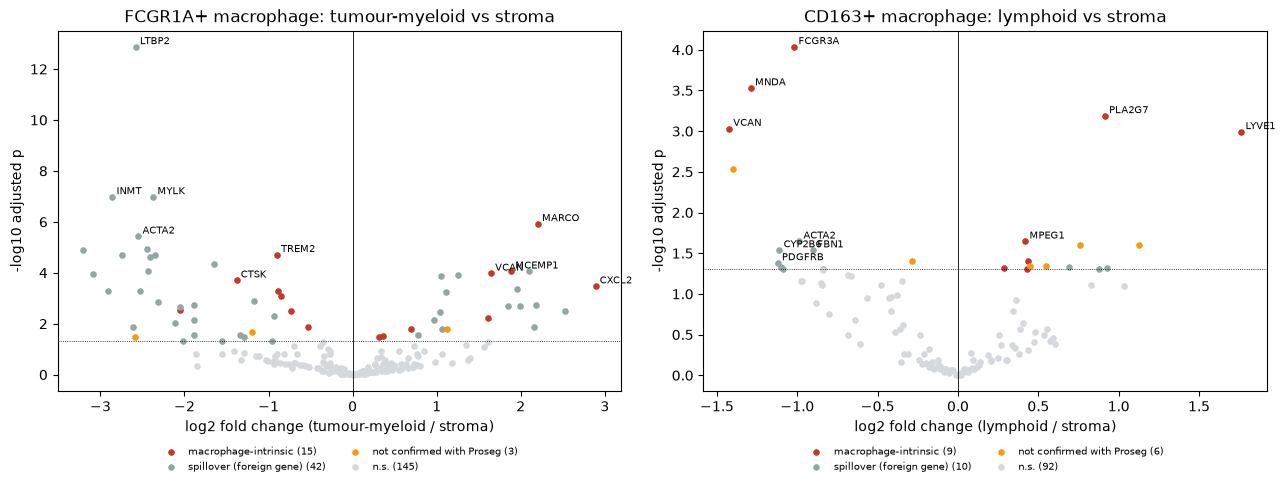

In [10]:
CALL_COLORS = {"macrophage-intrinsic": "#c0392b", "spillover (foreign gene)": "#95a5a6",
               "not confirmed with Proseg": "#f39c12", "n.s.": "#d5d8dc"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (cell_type, a_role, b_role) in zip(axes, COMPARISONS):
    r = de[cell_type].dropna(subset=["padj"])
    for call, col in CALL_COLORS.items():
        s = r[r["call"] == call]
        ax.scatter(s["log2FoldChange"], -np.log10(s["padj"].clip(lower=1e-30)), s=14, color=col, label=f"{call} ({len(s)})")
    lab = pd.concat([r[r["call"] == "macrophage-intrinsic"].nsmallest(6, "padj"),
                     r[r["call"] == "spillover (foreign gene)"].nsmallest(4, "padj")])
    for g, row in lab.iterrows():
        ax.annotate(g, (row["log2FoldChange"], -np.log10(max(row["padj"], 1e-30))), fontsize=7, xytext=(3, 2), textcoords="offset points")
    ax.axhline(-np.log10(0.05), color="black", lw=0.6, ls=":")
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel(f"log2 fold change ({a_role} / {b_role})")
    ax.set_ylabel("-log10 adjusted p")
    ax.set_title(f"{cell_type}: {a_role} vs {b_role}")
    ax.legend(fontsize=7, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
plt.tight_layout()
plt.show()

**Reading E.**

**FCGR1A+ macrophages, tumour-myeloid zone vs stroma.** 15 genes pass every filter:
- *Higher in the tumour-myeloid zone:* MARCO and MCEMP1 (alveolar-macrophage genes), CXCL2 (neutrophil-attracting chemokine), VCAN and AQP9 (monocyte-derived, inflammatory). In this zone alveolar macrophages are the most common myeloid cell (~40%): it is where tumour borders open into airspaces.
- *Higher in stroma:* TREM2, CTSK, LPL and PLA2G7: the lipid-handling, matrix-remodelling programme described for TREM2+ tumour-associated macrophages.
- 42 of the significant genes were **spillover** (fibroblast genes such as THBS2, FBN1, ACTA2 in stromal macrophages; KRT7 in tumour-zone ones). Without the filter they would have been the top hits.
- **Caveat:** the filter only removes genes of *other lineages*. MARCO and MCEMP1 are myeloid genes, so spillover from neighbouring alveolar macrophages, which are abundant in this zone, cannot be excluded by this test; Proseg confirming them (log2FC +2.5 and +1.6) makes it less likely, but not impossible.

**CD163+ macrophages, lymphoid aggregates vs stroma.** A smaller shift (9 genes): LYVE1, PLA2G7, CXCR4 and MPEG1 higher in lymphoid aggregates; FCGR3A, MNDA and VCAN (monocyte-like genes) lower. CD163+ macrophages inside lymphoid aggregates look more tissue-resident (LYVE1+) and less recently monocyte-derived.

**What this shows:** the same annotated macrophage type carries different programmes depending on its domain, and most of the naive differential expression in imaging data is spillover from the neighbourhood. Filtering foreign genes and confirming with a second segmentation is what separates the two.

## F. Export for Xenium Explorer

Each labelling is written as a **cell groups** CSV (`cell_id, group, color`), the format Xenium Explorer imports under *Cell* > *Add cell categorization*. Anyone with the Xenium bundle can then browse cell types, niches and domains on the tissue, over the morphology and H&E images.

In [11]:
EXPLORER_DIR = OUT_DIR / "xenium_explorer"
EXPLORER_DIR.mkdir(exist_ok=True)
groupings = {"cell_types": adata.obs["cell_type"].astype(str), "lineages": lineage, "niches_kmeans": domains["niche"],
             "domains_banksy": domains["banksy"], "domains_cellcharter": domains["cellcharter"]}
for name, labels in groupings.items():   # Xenium Explorer cell groups: cell_id, group, color
    dm.explorer_groups(labels, adata.obs_names, xu.LINEAGE_COLORS if name == "lineages" else None) \
        .to_csv(EXPLORER_DIR / f"{name}.csv", index=False)
domains.to_csv(OUT_DIR / "domains.csv.gz", index_label="cell_id")
print(f"Saved {len(groupings)} cell-group files to {xu.display_path(EXPLORER_DIR)}")
print(f"Saved all domain labels to {xu.display_path(OUT_DIR / 'domains.csv.gz')}")
for name, r in de.items():
    r.to_csv(OUT_DIR / f"pseudobulk_de_{name.split('+')[0].lower()}.csv")

Saved 5 cell-group files to ~/data/xenium_lung/processed/spatial_domains/xenium_explorer
Saved all domain labels to ~/data/xenium_lung/processed/spatial_domains/domains.csv.gz


## Conclusions

1. **Domains are reproducible at the compartment level.** k-means niches, BANKSY and CellCharter agree on the tumour / immune / stroma compartment of 79-86% of cells, and all three recover the lymphoid aggregates, a myeloid-rich tumour zone, vessels and stroma.
2. **The methods split the tumour along different axes.** BANKSY by tumour programme (regions dominated by one subtype), CellCharter by architecture (nest core vs edge). Low ARI between methods reflects that difference, not failure; the choice of method should follow the question.
3. **Stability was measured, not assumed:** BANKSY's chosen map agrees with neighbouring settings at ARI ~0.8; CellCharter chose K = 7 as its most stable number of domains, and needed explicit PyTorch seeding to be reproducible.
4. **Macrophage state depends on location.** FCGR1A+ macrophages express an alveolar / inflammatory programme (MARCO, MCEMP1, CXCL2) in the tumour-myeloid zone and a TREM2 / CTSK / LPL programme in stroma; CD163+ macrophages in lymphoid aggregates are LYVE1-high and monocyte-gene-low.
5. **Spillover is the dominant artefact in spatial differential expression.** 42 of 60 significant genes in the first comparison were neighbouring-lineage genes. Results are reported only when they survive a foreign-gene filter and the Proseg counts.
6. **Limits:** one section, so blocks are pseudo-replicates and p-values are optimistic; within-lineage spillover (e.g. from alveolar macrophages) is not excluded by the filter.

The cell-group files in `xenium_explorer/` load into Xenium Explorer for interactive browsing of all labellings.